# Exaustive machine learning project (housing prices) : exploration and predictions

# **Loading data**

In this first section we just load and format our train data, and we define a funtion and will allow us to do polynomial regression easily

In [1]:
!pip install -q optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 6.5 MB/s eta 0:00:00


In [2]:
!pip install -q catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.6 MB/s eta 0:00:00


In [3]:
!pip install -q skoptimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.9/100.9 kB 2.2 MB/s eta 0:00:00


In [4]:
import pandas as pd
from math import nan
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from catboost import CatBoostRegressor
from catboost import CatBoostRegressor, Pool

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, root_mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import ElasticNetCV
from sklearn.neighbors import KNeighborsRegressor

from sklearn.decomposition import PCA

import optuna

from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

In [5]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
def get_best_regression_degree(data_X, data_y, model, range=range(1, 100)):
  scores = pd.Series(index=range)
  for d in range :
    print('\n degree in process : ', d)
    polynomial_converter = PolynomialFeatures(degree=d, include_bias=False)
    poly_data_X = polynomial_converter.fit_transform(data_X)
    print('number of features : ', np.shape(poly_data_X)[1])
    score = cross_val_score(model, poly_data_X, data_y, cv=5, scoring='neg_mean_absolute_percentage_error').mean()
    scores[d]=score
    print('mean_absolute_percentage_error (mean CV): ', -score)
    model.fit(poly_data_X, data_y)
    print('mean_absolute_percentage_error (on the training set) : ', mean_absolute_percentage_error(data_y, model.predict(poly_data_X)))

  return np.argmax(scores), np.max(score)

# **Data Preprocessing**

In this section, we
- put the features into the right data structure
- deal with missing values (replace or drop)
- Data Preparation : create different versions of the dataset to apply the models flexibly later (X_train, X_test, y_train, y_test, scaled features, only numerical features, etc)

## Data Cleaning

Here, we will clean the dataset by changing the variable type in order to fit the expectations of the models for the training set

***useful quality dict***

In [7]:
Qual_dict = {
    'Po' : 0,
    'Fa' : 1,
    'TA' : 2,
    'Gd' : 3,
    'Ex' : 4
}

### num to cat

**MSSubClass** : Num to Cat

This variable identifies the type of dwelling involved in the sale.

In [8]:
df.MSSubClass.value_counts()

,count
MSSubClass,
20,536
60,299
50,144
120,87
30,69
160,63
70,60
80,58
90,52


In [9]:
MSSubClass_dict =  {20  :  '1-STORY 1946 & NEWER ALL STYLES',
                    30  :  '1-STORY 1945 & OLDER',
                    40  :  '1-STORY W/FINISHED ATTIC ALL AGES',
                    45  :  '1-1/2 STORY - UNFINISHED ALL AGES',
                    50  :  '1-1/2 STORY FINISHED ALL AGES',
                    60  :  '2-STORY 1946 & NEWER',
                    70  :  '2-STORY 1945 & OLDER',
                    75  :  '2-1/2 STORY ALL AGES',
                    80  :  'SPLIT OR MULTI-LEVEL',
                    85  :  'SPLIT FOYER',
                    90  :  'DUPLEX - ALL STYLES AND AGES',
                    120  :  '1-STORY PUD (Planned Unit Development) - 1946 & NEWER',
                    150  :  '1-1/2 STORY PUD - ALL AGES',
                    160  :  '2-STORY PUD - 1946 & NEWER',
                    180  :  'PUD - MULTILEVEL - INCL SPLIT LEV/FOYER',
                    190  :  '2 FAMILY CONVERSION - ALL STYLES AND AGES'
                    }

df['MSSubClass'] = df['MSSubClass'].apply(lambda n: MSSubClass_dict[n])
df.MSSubClass.value_counts()

,count
MSSubClass,
1-STORY 1946 & NEWER ALL STYLES,536
2-STORY 1946 & NEWER,299
1-1/2 STORY FINISHED ALL AGES,144
1-STORY PUD (Planned Unit Development) - 1946 & NEWER,87
1-STORY 1945 & OLDER,69
2-STORY PUD - 1946 & NEWER,63
2-STORY 1945 & OLDER,60
SPLIT OR MULTI-LEVEL,58
DUPLEX - ALL STYLES AND AGES,52


In [10]:
# MSSubClass_dict =  {20  :  'A',
#                     30  :  'B',
#                     40  :  'C',
#                     45  :  'D',
#                     50  :  'E',
#                     60  :  'F',
#                     70  :  'G',
#                     75  :  'H',
#                     80  :  'I',
#                     85  :  'J',
#                     90  :  'K',
#                     120  :  'L',
#                     150  :  'M',
#                     160  :  'N',
#                     180  :  'O',
#                     190  :  'P'
#                     }

# df['MSSubClass'] = df['MSSubClass'].apply(lambda n: MSSubClass_dict[n])
# df.MSSubClass.value_counts()

### cat to bin

**Street** : Cat to Bin

This variable represents the type of road access to property (material)

In [11]:
df.Street.value_counts()

,count
Street,
Pave,1454
Grvl,6


In [12]:
df.Street = df.Street.apply(lambda a: 0 if a=='Pave' else 1)
df.Street.value_counts()

,count
Street,
0,1454
1,6


Type of alley access to property (material)

In [13]:
df.Alley.value_counts()

,count
Alley,
Grvl,50
Pave,41


In [14]:
df.Alley = df.Alley.fillna('NA')
df.Alley.value_counts()

,count
Alley,
NA,1369
Grvl,50
Pave,41


**CentralAir** : Cat to Bin

This variable represents central air conditioning

In [15]:
df.CentralAir.value_counts()

,count
CentralAir,
Y,1365
N,95


In [16]:
df['CentralAir'] = df['CentralAir'].apply(lambda a: 0 if a=='N' else 1)
df.CentralAir.value_counts()

,count
CentralAir,
1,1365
0,95


### cat to num

**LotShape** : name change (from LotShape to LotIrregularity)

**LotIrregularity** : Cat to Num

In [17]:
df.LotShape.value_counts()

,count
LotShape,
Reg,925
IR1,484
IR2,41
IR3,10


In [18]:
LotShape_dict = {
    'Reg' : 0,
    'IR1' : 1,
    'IR2' : 2,
    'IR3' : 3
}

df['LotIrregularity'] = df.LotShape.apply(lambda a: LotShape_dict[a])
df.drop('LotShape', axis=1)
df = df.drop('LotShape', axis=1)
df['LotIrregularity'].value_counts()

,count
LotIrregularity,
0,925
1,484
2,41
3,10


**LandSlope** : Cat to Num

In [19]:
df.LandSlope.value_counts()

,count
LandSlope,
Gtl,1382
Mod,65
Sev,13


In [20]:
LandSlope_dict = {
    'Gtl' : 1,
    'Mod' : 2,
    'Sev' : 3
}

df['LandSlope'] = df.LandSlope.apply(lambda a: LandSlope_dict[a])
df['LandSlope'].value_counts()

,count
LandSlope,
1,1382
2,65
3,13


**ExterQual** : Cat to Num

In [21]:
df.ExterQual.value_counts()

,count
ExterQual,
TA,906
Gd,488
Ex,52
Fa,14


In [22]:
df['ExterQual'] = df['ExterQual'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df.ExterQual.value_counts()

,count
ExterQual,
2,906
3,488
4,52
1,14


**ExterCond** : Cat to Num

In [23]:
df.ExterCond.value_counts()

,count
ExterCond,
TA,1282
Gd,146
Fa,28
Ex,3
Po,1


In [24]:
df['ExterCond'] = df['ExterCond'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df.ExterCond.value_counts()

,count
ExterCond,
2,1282
3,146
1,28
4,3
0,1


**HeatingQC** : Cat to Num

In [25]:
df.HeatingQC.value_counts()

,count
HeatingQC,
Ex,741
TA,428
Gd,241
Fa,49
Po,1


In [26]:
df['HeatingQC'] = df['HeatingQC'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df.HeatingQC.value_counts()

,count
HeatingQC,
4,741
2,428
3,241
1,49
0,1


**KitchenQual** : Cat to Num

In [27]:
df.KitchenQual.value_counts()

,count
KitchenQual,
TA,735
Gd,586
Ex,100
Fa,39


In [28]:
df['KitchenQual'] = df['KitchenQual'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df.KitchenQual.value_counts()

,count
KitchenQual,
2,735
3,586
4,100
1,39


**FireplaceQu** : Cat to Num

In [29]:
df.FireplaceQu.value_counts()

,count
FireplaceQu,
Gd,380
TA,313
Fa,33
Ex,24
Po,20


In [30]:
df['FireplaceQu'] = df['FireplaceQu'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df['FireplaceQu'] = df['FireplaceQu'].fillna(-1)
df.FireplaceQu.value_counts()

,count
FireplaceQu,
-1.0,690
3.0,380
2.0,313
1.0,33
4.0,24
0.0,20


### about basement

**BsmtQual** : Cat to Num

In [31]:
df.BsmtQual.value_counts()

,count
BsmtQual,
TA,649
Gd,618
Ex,121
Fa,35


In [32]:
df['BsmtQual'] = df['BsmtQual'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df['BsmtQual'] = df['BsmtQual'].fillna(-1)
df.BsmtQual.value_counts()

,count
BsmtQual,
2.0,649
3.0,618
4.0,121
-1.0,37
1.0,35


**BsmtCond** : Cat to Num

In [33]:
df.BsmtCond.value_counts()

,count
BsmtCond,
TA,1311
Gd,65
Fa,45
Po,2


In [34]:
df['BsmtCond'] = df['BsmtCond'].apply(lambda a: Qual_dict[a] if type(a)==str else nan)
df['BsmtCond'] = df['BsmtCond'].fillna(-1)
df.BsmtCond.value_counts()

,count
BsmtCond,
2.0,1311
3.0,65
1.0,45
-1.0,37
0.0,2


**BsmtExposureExist** : variable created from BsmtExposure 'No' category

In [35]:
df.BsmtExposure.value_counts()

,count
BsmtExposure,
No,953
Av,221
Gd,134
Mn,114


In [36]:
BsmtExposure_array = np.ones(len(df))
BsmtExposure_array[df[df['BsmtExposure']=='No'].index]=0
df['BsmtExposureExist']=BsmtExposure_array.astype(int)
df.BsmtExposureExist.value_counts()

,count
BsmtExposureExist,
0,953
1,507


**BsmtExist** : variable created from BsmtCond NaN's

In [37]:
BsmtExist_array = np.ones(len(df))
BsmtExist_array[df[df['BsmtFinType1'].isnull()].index]=0
df['BsmtExist']=BsmtExist_array.astype(int)
df.BsmtExist.value_counts()

,count
BsmtExist,
1,1423
0,37


**BsmtExposure** : Cat to Num

In [38]:
df.BsmtExposure.value_counts()

,count
BsmtExposure,
No,953
Av,221
Gd,134
Mn,114


In [39]:
BsmtExposure_dict = {
    'Gd' : 3,
    'Av' : 2,
    'Mn' : 1,
    'No' : 0
}

df['BsmtExposure'] = df['BsmtExposure'].apply(lambda a: BsmtExposure_dict[a] if type(a)==str else nan)
df['BsmtExposure'] = df['BsmtExposure'].fillna(-1)
df.BsmtExposure.value_counts()

,count
BsmtExposure,
0.0,953
2.0,221
3.0,134
1.0,114
-1.0,38


### about garage

**GarageFinish** : Cat to Num

In [40]:
df.GarageFinish.value_counts()

,count
GarageFinish,
Unf,605
RFn,422
Fin,352


In [41]:
GarageFinish_dict = {
    'Unf' : 1,
    'RFn' : 2,
    'Fin' : 3
}

df['GarageFinish'] = df['GarageFinish'].apply(lambda a: GarageFinish_dict[a] if type(a)==str else -1)
df.GarageFinish.value_counts()

,count
GarageFinish,
1,605
2,422
3,352
-1,81


**GarageQual** : Cat to Num

In [42]:
df.GarageQual.value_counts()

,count
GarageQual,
TA,1311
Fa,48
Gd,14
Ex,3
Po,3


In [43]:
GarageQual_dict = {
    'Po' : 0,
    'Fa' : 1,
    'TA' : 2,
    'Gd' : 3,
    'Ex' : 4
}

df['GarageQual'] = df['GarageQual'].apply(lambda a: GarageQual_dict[a] if type(a)==str else -1)
df.GarageQual.value_counts()

,count
GarageQual,
2,1311
-1,81
1,48
3,14
4,3
0,3


**GarageCond** : Cat to Num

In [44]:
df.GarageCond.value_counts()

,count
GarageCond,
TA,1326
Fa,35
Gd,9
Po,7
Ex,2


In [45]:
GarageCond_dict = {
    'Po' : 0,
    'Fa' : 1,
    'TA' : 2,
    'Gd' : 3,
    'Ex' : 4
}

df['GarageCond'] = df['GarageCond'].apply(lambda a: GarageCond_dict[a] if type(a)==str else -1)
df.GarageCond.value_counts()

,count
GarageCond,
2,1326
-1,81
1,35
3,9
0,7
4,2


**GarageExist** : variable created from GarageType NaN values

In [46]:
GarageExist_array = np.ones(len(df))
GarageExist_array[df[df['GarageType'].isnull()].index]=0
df['GarageExist']=GarageExist_array.astype(int)
df.GarageExist.value_counts()

,count
GarageExist,
1,1379
0,81


### about pool

**PoolExist** : variable created from PoolQC NaN values

In [47]:
PoolExist_array = np.ones(len(df))
PoolExist_array[df[df['PoolQC'].isnull()].index]=0
df['PoolExist']=PoolExist_array.astype(int)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotIrregularity,BsmtExposureExist,BsmtExist,GarageExist,PoolExist
0,1,2-STORY 1946 & NEWER,RL,65.0,8450,0,NA,Lvl,AllPub,Inside,1,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,3,2,PConc,3.0,2.0,0.0,GLQ,706,Unf,0,150,856,GasA,4,1,SBrkr,856,854,0,1710,1,0,2,1,3,1,3,8,Typ,0,-1.0,Attchd,2003.0,2,2,548,2,2,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500,0,0,1,1,0
1,2,1-STORY 1946 & NEWER ALL STYLES,RL,80.0,9600,0,NA,Lvl,AllPub,FR2,1,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,2,2,CBlock,3.0,2.0,3.0,ALQ,978,Unf,0,284,1262,GasA,4,1,SBrkr,1262,0,0,1262,0,1,2,0,3,1,2,6,Typ,1,2.0,Attchd,1976.0,2,2,460,2,2,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500,0,1,1,1,0
2,3,2-STORY 1946 & NEWER,RL,68.0,11250,0,NA,Lvl,AllPub,Inside,1,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,3,2,PConc,3.0,2.0,1.0,GLQ,486,Unf,0,434,920,GasA,4,1,SBrkr,920,866,0,1786,1,0,2,1,3,1,3,6,Typ,1,2.0,Attchd,2001.0,2,2,608,2,2,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500,1,1,1,1,0
3,4,2-STORY 1945 & OLDER,RL,60.0,9550,0,NA,Lvl,AllPub,Corner,1,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,2,2,BrkTil,2.0,3.0,0.0,ALQ,216,Unf,0,540,756,GasA,3,1,SBrkr,961,756,0,1717,1,0,1,0,3,1,3,7,Typ,1,3.0,Detchd,1998.0,1,3,642,2,2,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000,1,0,1,1,0
4,5,2-STORY 1946 & NEWER,RL,84.0,14260,0,NA,Lvl,AllPub,FR2,1,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,3,2,PConc,3.0,2.0,2.0,GLQ,655,Unf,0,490,1145,GasA,4,1,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,3,9,Typ,1,2.0,Attchd,2000.0,2,3,836,2,2,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000,1,1,1,1,0


**PoolQC** : Cat to Num

In [48]:
df.PoolQC.value_counts()

,count
PoolQC,
Gd,3
Ex,2
Fa,2


In [49]:
PoolQC_dict = {
    'Po' : 0,
    'Fa' : 1,
    'TA' : 2,
    'Gd' : 3,
    'Ex' : 4
}

df['PoolQC'] = df['PoolQC'].apply(lambda a: PoolQC_dict[a] if type(a)==str else -1)
df.PoolQC.value_counts()

,count
PoolQC,
-1,1453
3,3
4,2
1,2


### about fence

In [50]:
df.Fence.value_counts()

,count
Fence,
MnPrv,157
GdPrv,59
GdWo,54
MnWw,11


**FenceExist** :  variable created from Fence NaN values

In [51]:
FenceExist_array = np.ones(len(df))
FenceExist_array[df[df['Fence'].isnull()].index]=0
df['FenceExist']=FenceExist_array.astype(int)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,LotIrregularity,BsmtExposureExist,BsmtExist,GarageExist,PoolExist,FenceExist
0,1,2-STORY 1946 & NEWER,RL,65.0,8450,0,NA,Lvl,AllPub,Inside,1,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,3,2,PConc,3.0,2.0,0.0,GLQ,706,Unf,0,150,856,GasA,4,1,SBrkr,856,854,0,1710,1,0,2,1,3,1,3,8,Typ,0,-1.0,Attchd,2003.0,2,2,548,2,2,Y,0,61,0,0,0,0,-1,NaN,NaN,0,2,2008,WD,Normal,208500,0,0,1,1,0,0
1,2,1-STORY 1946 & NEWER ALL STYLES,RL,80.0,9600,0,NA,Lvl,AllPub,FR2,1,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,2,2,CBlock,3.0,2.0,3.0,ALQ,978,Unf,0,284,1262,GasA,4,1,SBrkr,1262,0,0,1262,0,1,2,0,3,1,2,6,Typ,1,2.0,Attchd,1976.0,2,2,460,2,2,Y,298,0,0,0,0,0,-1,NaN,NaN,0,5,2007,WD,Normal,181500,0,1,1,1,0,0
2,3,2-STORY 1946 & NEWER,RL,68.0,11250,0,NA,Lvl,AllPub,Inside,1,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,3,2,PConc,3.0,2.0,1.0,GLQ,486,Unf,0,434,920,GasA,4,1,SBrkr,920,866,0,1786,1,0,2,1,3,1,3,6,Typ,1,2.0,Attchd,2001.0,2,2,608,2,2,Y,0,42,0,0,0,0,-1,NaN,NaN,0,9,2008,WD,Normal,223500,1,1,1,1,0,0
3,4,2-STORY 1945 & OLDER,RL,60.0,9550,0,NA,Lvl,AllPub,Corner,1,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,2,2,BrkTil,2.0,3.0,0.0,ALQ,216,Unf,0,540,756,GasA,3,1,SBrkr,961,756,0,1717,1,0,1,0,3,1,3,7,Typ,1,3.0,Detchd,1998.0,1,3,642,2,2,Y,0,35,272,0,0,0,-1,NaN,NaN,0,2,2006,WD,Abnorml,140000,1,0,1,1,0,0
4,5,2-STORY 1946 & NEWER,RL,84.0,14260,0,NA,Lvl,AllPub,FR2,1,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,3,2,PConc,3.0,2.0,2.0,GLQ,655,Unf,0,490,1145,GasA,4,1,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,3,9,Typ,1,2.0,Attchd,2000.0,2,3,836,2,2,Y,192,84,0,0,0,0,-1,NaN,NaN,0,12,2008,WD,Normal,250000,1,1,1,1,0,0


### special cases

**LotFrontage** : NaN becomes 0 as a numerical value

The variable LotFrontage represent the linear feet of street connected to property

In [52]:
df.LotFrontage.isnull().sum()

np.int64(259)

In [53]:
df.LotFrontage = df.LotFrontage.fillna(0)
df.LotFrontage.isnull().sum()

np.int64(0)

**MasVnrType** : NaN becomes 'NA' as a category

In [54]:
df.MasVnrType.value_counts()

,count
MasVnrType,
BrkFace,445
Stone,128
BrkCmn,15


In [55]:
df.MasVnrType.isnull().sum()

np.int64(872)

In [56]:
df.MasVnrType = df.MasVnrType.fillna('NA')
df.MasVnrType.isnull().sum()

np.int64(0)

In [57]:
df.MasVnrType.value_counts()

,count
MasVnrType,
NA,872
BrkFace,445
Stone,128
BrkCmn,15


**Electric** : column number reduction

In [58]:
df.Electrical = df.Electrical.fillna('NA')
df.Electrical = df.Electrical.apply(lambda a: 'Other' if a in ['FuseP', 'Mix', 'NA'] else a)
df.Electrical.value_counts()

,count
Electrical,
SBrkr,1334
FuseA,94
FuseF,27
Other,5


**MasVnrArea** : null becomes 0 square feets

In [59]:
df.MasVnrArea = df.MasVnrArea.fillna(0)

**MiscFeature** : replace NaN by the category 'NA' (as no other feature is added)

In [60]:
df.MiscFeature = df.MiscFeature.fillna('NA')

## Data Preparation

We
- drop all remaining missing values so that our predictive models can train on the dataset
- create different all the different versions of the dataset to be able to play with them when we run predictive models
- Not very legal but thee will be leakage of final_test categories to train features (when applying get_dummies to train+test data at once)

We drop *GarageYrBlt* (garage year built) because :

1) it is very correlated to another variable named *YearBuilt*, witch is more relevant

2) it has too many missing values (when there is no garage), and missing values and hard to deal with in numerical features because they can not be created as a seperate class with one-hot encoding. Replacing missing values with an outlier like 0 could work but some models could have a bias interpreting 0 as a year (even though we had to use this method in previous data cleaning for important numerical features with missing values)

In [61]:
df = df.drop(['Id', 'GarageYrBlt'], axis=1)

In [62]:
df.isnull().sum()[df.isnull().sum()!=0]

,0
BsmtFinType1,37
BsmtFinType2,38
GarageType,81
Fence,1179


*BsmtFinType1* and *BsmtFinType2* have missing values that correspond to the category 0 in the feature *BsmtExist*. So there is no need to create a new binary feature for missing values during one-hot encoding as we already have it (*BsmtExist*)

The same for *GarageType* as we already have the *GarageExist* feature, and fence as we have *FenceExist* feature

In [63]:
len(df)

1460

In [64]:
df = pd.get_dummies(df)

In [65]:
df.head()

,LotFrontage,LotArea,Street,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,ExterQual,ExterCond,BsmtQual,BsmtCond,BsmtExposure,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Fireplaces,FireplaceQu,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,MiscVal,MoSold,YrSold,SalePrice,LotIrregularity,BsmtExposureExist,BsmtExist,GarageExist,PoolExist,FenceExist,MSSubClass_1-1/2 STORY - UNFINISHED ALL AGES,MSSubClass_1-1/2 STORY FINISHED ALL AGES,MSSubClass_1-STORY 1945 & OLDER,MSSubClass_1-STORY 1946 & NEWER ALL STYLES,MSSubClass_1-STORY PUD (Planned Unit Development) - 1946 & NEWER,MSSubClass_1-STORY W/FINISHED ATTIC ALL AGES,MSSubClass_2 FAMILY CONVERSION - ALL STYLES AND AGES,MSSubClass_2-1/2 STORY ALL AGES,MSSubClass_2-STORY 1945 & OLDER,MSSubClass_2-STORY 1946 & NEWER,MSSubClass_2-STORY PUD - 1946 & NEWER,MSSubClass_DUPLEX - ALL STYLES AND AGES,MSSubClass_PUD - MULTILEVEL - INCL SPLIT LEV/FOYER,MSSubClass_SPLIT FOYER,MSSubClass_SPLIT OR MULTI-LEVEL,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Alley_Grvl,Alley_NA,Alley_Pave,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_ClyTile,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkCmn,MasVnrType_BrkFace,MasVnrType_NA,MasVnrType_Stone,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtFinType1_ALQ,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_ALQ,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,Electrical_FuseA,Electrical_FuseF,Electrical_Other,Electrical_SBrkr,Functional_Maj1,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_2Types,GarageType_A

In [66]:
X, y = df.drop('SalePrice', axis=1), df['SalePrice']

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)
train = X_train.copy()
train['y'] = y_train

scaler = StandardScaler()
numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']

# scaled
scaled_X_train = pd.DataFrame(scaler.fit_transform(X_train), columns = X_train.columns, index = X_train.index)
scaled_X_test = pd.DataFrame(scaler.transform(X_test), columns = X_test.columns, index = X_test.index)

scaled_train = scaled_X_train.copy()
scaled_train['y'] = y_train.sort_index()


# numer
numer_X_train = X_train.select_dtypes(include=numerics)
numer_X_train = numer_X_train[numer_X_train.columns[:-5].tolist()]

numer_X_test = X_test.select_dtypes(include=numerics)
numer_X_test = numer_X_test[numer_X_test.columns[:-5].tolist()]

numer_train = numer_X_train.copy()
numer_train['y']= y_train.sort_index()


# numer + scaled
numer_scaled_X_train = pd.DataFrame(scaler.fit_transform(numer_X_train), columns = numer_X_train.columns, index = numer_X_train.index)
numer_scaled_X_test = pd.DataFrame(scaler.transform(numer_X_test), columns = numer_X_test.columns, index = numer_X_test.index)

numer_scaled_train = numer_scaled_X_train.copy()
numer_scaled_train['y'] = y_train.sort_index()

# **Dimentionnality reduction**
- RF feature selection
- PCA
- CCA

## Feature selection with Random Forest

Creation of a new version of the feature set that involves only the most relevant features according to the random forest regressor model

Because we noticed (further away in this notebook), that for every model, the results are either the same or improve when the dataset is only numerical (no dummy variables), we want to get the feature importances to verify our hypotesis that the categorical features don't have an impact on the price, and have a look on the most relevant features for price prediction. We will use the Random forest model as it is quite reliable on this field. Remember that the feature importances will be given in percentages, so they sum up to 100.

In [68]:
model = RandomForestRegressor()
model.fit(scaled_X_train, y_train)
preds = model.predict(scaled_X_test)

In [69]:
mean_absolute_percentage_error(y_test, preds)

0.09364142052081363

In [70]:
root_mean_squared_error(y_test, preds)

30213.05206334105

In [71]:
fi = pd.DataFrame([model.feature_names_in_, model.feature_importances_]).T.sort_values(1, ascending=False)
fi[1]=fi[1]*100
fi.head()

,0,1
4,OverallQual,56.388412
23,GrLivArea,11.232232
17,TotalBsmtSF,4.142377
14,BsmtFinSF1,2.992815
21,2ndFlrSF,2.441999


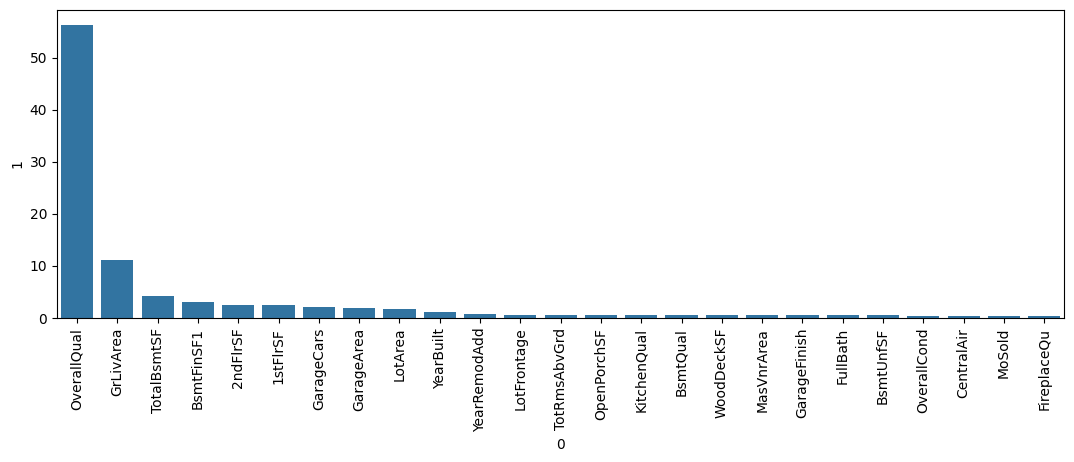

In [72]:
plt.figure(figsize=(13, 4))
sns.barplot(x=fi[0].iloc[:25], y=fi[1].iloc[:25])
plt.xticks(rotation=90)
plt.show()

Our hypotesis is verified as no dummy variable is present in the 25 most important features, that gather combined 95 percent of the importance for price prediction. We will later perform the ANOVA test in order to verify if there are still categorical variables that are linked to price

--> let's create a new dataset only with these features

In [73]:
fi[0].head(25).values.tolist()

['OverallQual',
 'GrLivArea',
 'TotalBsmtSF',
 'BsmtFinSF1',
 '2ndFlrSF',
 '1stFlrSF',
 'GarageCars',
 'GarageArea',
 'LotArea',
 'YearBuilt',
 'YearRemodAdd',
 'LotFrontage',
 'TotRmsAbvGrd',
 'OpenPorchSF',
 'KitchenQual',
 'BsmtQual',
 'WoodDeckSF',
 'MasVnrArea',
 'GarageFinish',
 'FullBath',
 'BsmtUnfSF',
 'OverallCond',
 'CentralAir',
 'MoSold',
 'FireplaceQu']

In [74]:
scaled_topfi_X_train = scaled_X_train[fi[0].head(25).values.tolist()]
scaled_topfi_X_test = scaled_X_test[fi[0].head(25).values.tolist()]
scaled_topfi_train = scaled_X_train.copy()
scaled_topfi_train['y']=y_train

In [75]:
len(scaled_topfi_X_test.T)

25

In [76]:
len(scaled_X_train)

1314

In [77]:
len(y_train)

1314

In [78]:
print(len(scaled_topfi_X_train))

1314


## PCA (+ drop outliers)

we will reduce the dimentionality of our data by creating components that don't have redondant information

The graph below represents the amount of information gathered from the original features according to the number of components that we keep

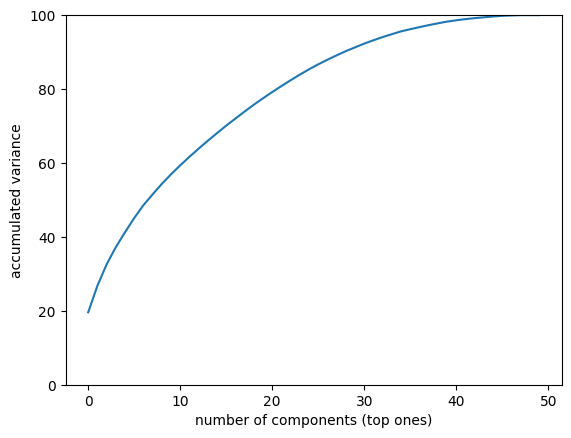

In [79]:
pca = PCA(n_components=len(numer_X_train.columns))

numer_scaled_pc_X_train = pd.DataFrame(pca.fit_transform(numer_scaled_X_train))


components_variance = pca.explained_variance_ratio_*100
components_variance_accumulated = np.array([components_variance[i] + np.sum(components_variance[:i]) for i in range(len(components_variance))])
pd.Series(components_variance_accumulated).plot()
plt.xlabel('number of components (top ones)')
plt.ylabel('accumulated variance')
plt.ylim(0, 100)
plt.show()

We want

--> as few components as possible

--> the highest possible accumulated variance (can be understood as the information gathered by the components)

We should note that the **component 1** gather as much variance as possible

**component 2** gather as much variance as possible witch has not been gathered by component 1

**component 3** gather as much variance as possible witch has not been gathered by component 1 and component 2

**etc**

- So the variance gathered decreases as we go through components from the top to the end one, but the accumulated variance increase (plot)

In [80]:
len(components_variance_accumulated[components_variance_accumulated<80])

21

**If we want to keep 80 percent of the initial variance, we would need to keep 21 components**
This seems to be a good trade-off

In [81]:
len(components_variance_accumulated[components_variance_accumulated<80])

21

In [82]:
pca = PCA(n_components=21)

numer_scaled_pc_X_train = pd.DataFrame(pca.fit_transform(numer_scaled_X_train), index = numer_scaled_X_train.index)
numer_scaled_pc_X_test = pd.DataFrame(pca.fit_transform(numer_scaled_X_test), index = numer_scaled_X_test.index)
numer_scaled_pc_train = numer_scaled_pc_X_train.copy()
numer_scaled_pc_train['y']=y_train.sort_index()

let's check the components that are mostly correlated to *y* (in terms of absolute value correlations)

In [83]:
abs(numer_scaled_pc_train.corr()['y']).drop('y').sort_values(ascending=False)*100

,y
0,86.573694
2,9.250682
1,8.468621
3,8.240268
4,7.458708
17,5.871146
5,5.091473
8,5.042899
11,4.963648
9,4.774039


*We can notice a very high correlation between component 1 and the output (86 percent), but the correlations don't necessarly go down with the component rank. As we can see, some low rank components (like component 17) are more correlated to y than high rank components (like component 7). This is because the information gathered with the pca components is not necessarly the one correlated to y. Therefore, for predictions purposes, we will not use pca components*

**As we remarked a very high correlation between component 1 and y, let's plot these 2 variables into a graph**

Text(0, 0.5, 'y')

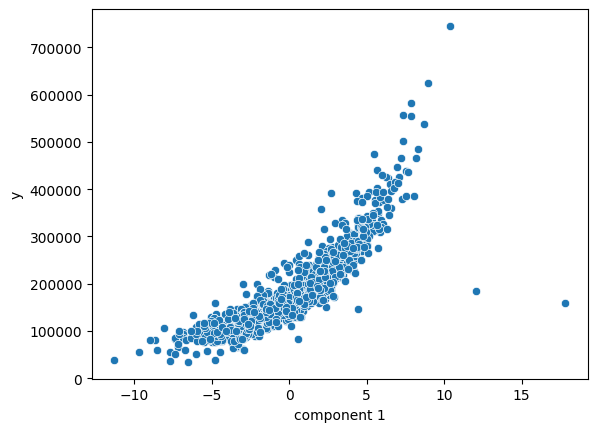

In [84]:
sns.scatterplot(x=numer_scaled_pc_train[0], y=numer_scaled_pc_train['y'])
plt.xlabel('component 1')
plt.ylabel('y')

It looks like the relationship is polynomial, so let's see what we would get from a polynomial regression curve (degree 2 will be sufficient)

In [85]:
poly_converter = PolynomialFeatures(degree = 2, include_bias=False)
numer_scaled_pc1_poly_X_train = pd.DataFrame(poly_converter.fit_transform(numer_scaled_pc_X_train[0].to_frame()), index = numer_scaled_pc_X_train.index)
numer_scaled_pc1_poly_X_test = pd.DataFrame(poly_converter.transform(numer_scaled_pc_X_test[0].to_frame()), index = numer_scaled_pc_X_test.index)

lr = LinearRegression()
lr.fit(numer_scaled_pc1_poly_X_train, y_train)

LinearRegression()

/tmp/ipython-input-2284223673.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x = numer_scaled_pc_train[0], y=preds, palette=['r'])


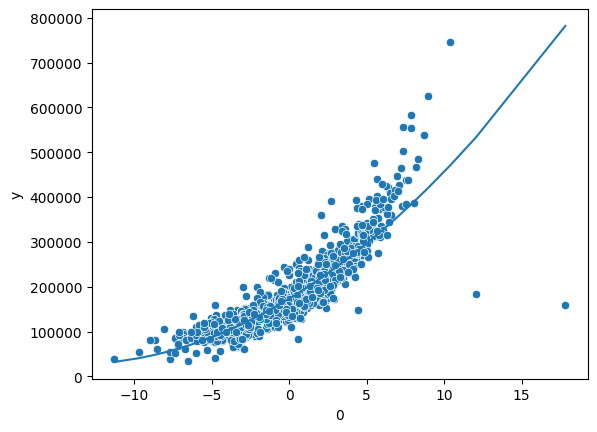

In [86]:
preds = lr.predict(numer_scaled_pc1_poly_X_train)

sns.scatterplot(x=numer_scaled_pc_train[0], y=numer_scaled_pc_train['y'])
sns.lineplot(x = numer_scaled_pc_train[0], y=preds, palette=['r'])
plt.show()

In [87]:
preds = lr.predict(numer_scaled_pc1_poly_X_test)
mape = mean_absolute_percentage_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)
print('mean absolute percentage error (test set) : ', mape)
print('root mean squared error (test set) : ', rmse)

mean absolute percentage error (test set) :  0.1154688783564347
root mean squared error (test set) :  35242.50848591702


It seems that the two ouliers in bottom down are bringing down the regression curve, preventing it to go though the real trend of the data.

Let's drop them to see if the curve fits better than real trend

In [88]:
index_outliers = numer_scaled_pc_train[(numer_scaled_pc_train[0]>10) & (numer_scaled_pc_train['y']<250000)].index

numer_scaled_pc_train = numer_scaled_pc_train.drop(index_outliers)
numer_scaled_pc_X_train = numer_scaled_pc_X_train.drop(index_outliers)

numer_scaled_train = numer_scaled_train.drop(index_outliers)
numer_scaled_X_train = numer_scaled_X_train.drop(index_outliers)

numer_train = numer_train.drop(index_outliers)
numer_X_train = numer_X_train.drop(index_outliers)

scaled_train = scaled_train.drop(index_outliers)
scaled_X_train = scaled_X_train.drop(index_outliers)

scaled_topfi_train = scaled_topfi_train.drop(index_outliers)
scaled_topfi_X_train = scaled_topfi_X_train.drop(index_outliers)

train = train.drop(index_outliers)
X_train = X_train.drop(index_outliers)

y_train = y_train.drop(index_outliers)

In [89]:
poly_converter = PolynomialFeatures(degree = 2, include_bias=False)
numer_scaled_pc1_poly_X_train = pd.DataFrame(poly_converter.fit_transform(numer_scaled_pc_X_train[0].to_frame()), index = numer_scaled_pc_X_train.index)
numer_scaled_pc1_poly_X_test = pd.DataFrame(poly_converter.transform(numer_scaled_pc_X_test[0].to_frame()), index = numer_scaled_pc_X_test.index)

lr = LinearRegression()
lr.fit(numer_scaled_pc1_poly_X_train, y_train)

LinearRegression()

/tmp/ipython-input-2284223673.py:4: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x = numer_scaled_pc_train[0], y=preds, palette=['r'])


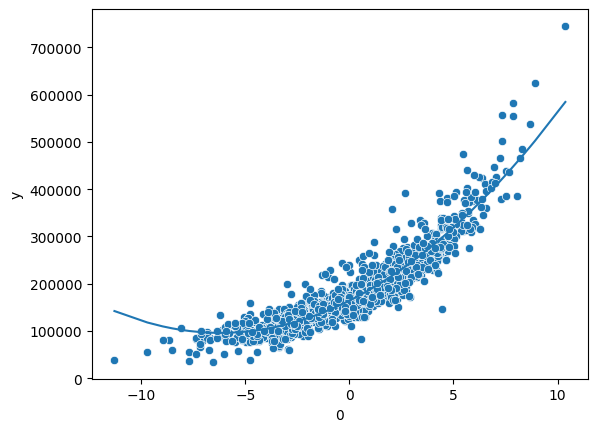

In [90]:
preds = lr.predict(numer_scaled_pc1_poly_X_train)

sns.scatterplot(x=numer_scaled_pc_train[0], y=numer_scaled_pc_train['y'])
sns.lineplot(x = numer_scaled_pc_train[0], y=preds, palette=['r'])
plt.show()

The curve seems better right now

In [91]:
preds = lr.predict(numer_scaled_pc1_poly_X_test)
mape = mean_absolute_percentage_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)
print('mean absolute percentage error (test set) : ', mape)
print('root mean squared error (test set) : ', rmse)

mean absolute percentage error (test set) :  0.11750698965179629
root mean squared error (test set) :  27589.819380393677


We also got better error metrics values on test set (especially root mean squared error)

## CCA (canonical correlation analysis)

we create the linear combination of our features that maximise the correlation with the output variable (price)

In [92]:
from sklearn.cross_decomposition import CCA

cca = CCA(n_components=1)
cca.fit(numer_scaled_X_train, y_train)
numer_scaled_cca_X_train = pd.DataFrame(cca.transform(numer_scaled_X_train), index = numer_scaled_X_train.index)
numer_scaled_cca_X_test = pd.DataFrame(cca.transform(numer_scaled_X_test), index = numer_scaled_X_test.index)

numer_scaled_cca_train = numer_scaled_cca_X_train.copy()
numer_scaled_cca_train['y']=y_train

correlation between the cca component and the price is 94 percent (pca component was 86 percent)

In [93]:
numer_scaled_cca_train.corr()['y'].loc[0]

np.float64(0.9400198235416348)

In [94]:
cca.coef_

array([[  7563.62631392,  10089.53477201,  -3910.08388614,
          1102.68180563,  28961.99418218,  15321.82710782,
         17033.02234918,  -2440.99988761,   7324.51971938,
         12973.07432579,  -1961.17428684,   6677.5316574 ,
        -13342.71713743,   9299.44686777,  20944.35563967,
          1415.93425325,   1878.53537379,  24864.0195844 ,
          2264.17211882,   -789.63720083,  15479.30397755,
         21844.46618481,  -2090.24255242,  30911.08688779,
          -780.38394915,  -3968.15503371,   -892.21243373,
          1235.9713586 , -14152.12315472, -12201.88568441,
         11180.92857145,  15240.34984311,   2108.92546489,
          1720.45123963,   -162.84065704,   2687.55565129,
         13510.05641872,   3236.9447995 , -12104.66196626,
          3550.95764986,   1303.4229808 ,  -1325.47713781,
           899.87816301,   3933.93208366,  -8448.01005143,
         15705.87360268,   -189.41687172,    117.33081927,
         -1006.7378746 ,   5318.01011887]])

In [95]:
# feature importances with random forest
fi.head()

,0,1
4,OverallQual,56.388412
23,GrLivArea,11.232232
17,TotalBsmtSF,4.142377
14,BsmtFinSF1,2.992815
21,2ndFlrSF,2.441999


In the following dataframe, we have the percentage of contribution in the creation of the cca component.

In [96]:
betas = pd.DataFrame([cca.coef_[0].tolist()], columns = numer_scaled_X_train.columns.tolist()).T
contributions = (abs(betas)/np.sum(abs(betas))).sort_values(by=0, ascending=False)*100
contributions.head()

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


,0
GrLivArea,7.777030
OverallQual,7.286651
TotalBsmtSF,6.255627
2ndFlrSF,5.495927
BsmtFinSF1,5.269465


we get something pretty similar to the selected features with random forest

Text(0, 0.5, 'y')

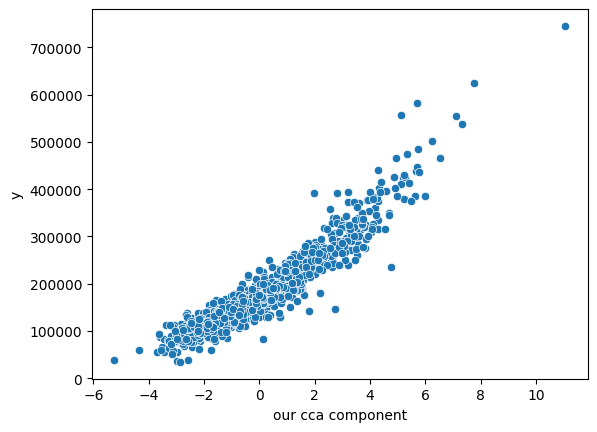

In [97]:
sns.scatterplot(x = numer_scaled_cca_X_train[0], y = y_train)
plt.xlabel('our cca component')
plt.ylabel('y')

In [98]:
lr = LinearRegression()
lr.fit(numer_scaled_cca_X_train, y_train)
preds = lr.predict(numer_scaled_cca_X_test)
mape = mean_absolute_percentage_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)

In [99]:
mape

0.11903715937965939

In [100]:
rmse

33971.0625693235

# **Prediction Models**

Accuracy generally improves with
- Number of predictive features
- Hyperparameter optimisation of a model

## Step 1 : train/testing different models on different dataset versions to choose the best pipeline for the final predictions in kaggle

### Models 1 : Random Forest Regressor [mape = 9.14%, rmse = 29722]
We will create and evaluate 3 versions of Random Forest Regressor

#### No Hyperparameter tuning (default ones)

In [ ]:
model = RandomForestRegressor()
model.fit(X_train, y_train)
preds1_1 = model.predict(X_test)

mean absolute percentage error

In [ ]:
mean_absolute_percentage_error(y_test, preds1_1)*100

9.141859553486507

mean absolute error

In [ ]:
mean_absolute_error(y_test, preds1_1)

16212.05904109589

root mean squared error

In [ ]:
root_mean_squared_error(y_test, preds1_1)

29867.40363544883

#### Hyperparameter tuning through GridSearchCV

In [ ]:
model = RandomForestRegressor()

param_grid = {
        "n_estimators"      : [50, 100, 150, 200],
        "max_features"      : ["sqrt", "log2", 1.0],
        "min_samples_split" : [2,4,8],
        "bootstrap": [True, False]
        }

cvmodel = GridSearchCV(model, param_grid, n_jobs=-1, cv=5, verbose = 5, scoring='neg_mean_squared_error')
cvmodel.fit(scaled_X_train, y_train)
preds1_2 = cvmodel.predict(scaled_X_test)

Fitting 5 folds for each of 72 candidates, totalling 360 fits


mean absolute percentage error

In [ ]:
mean_absolute_percentage_error(y_test, preds1_2)*100

9.38417165400243

mean absolute error

In [ ]:
mean_absolute_error(y_test, preds1_2)

16390.741849315065

root mean squared error

In [ ]:
root_mean_squared_error(y_test, preds1_2)

31544.814063023092

In [ ]:
cvmodel.best_params_

{'bootstrap': False,
 'max_features': 'sqrt',
 'min_samples_split': 2,
 'n_estimators': 200}

#### Hyperparameter tuning through Bayestian optimisation

In [103]:
def objective(trial):
    # Suggest values for hyperparameters
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 5, 30)
    min_samples_split = trial.suggest_int('min_samples_split', 2, 10)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 4)
    max_features = trial.suggest_categorical('max_features', ['sqrt', 'log2', None])

    # Create the model with suggested hyperparameters
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        random_state=42
    )

    # Evaluate the model using cross-validation
    score = cross_val_score(model, scaled_X_train, y_train, cv=5, scoring='neg_root_mean_squared_error').mean()
    print(score)

    # Return the negative score (Optuna minimizes by default)
    return score

study = optuna.create_study(direction='maximize')  # Minimize the objective function
study.optimize(objective, n_trials=150)  # Perform 150 trials

In [ ]:
best_params = study.best_params

final_model = RandomForestRegressor(**best_params, random_state=42)
final_model.fit(scaled_X_train, y_train)

preds1_3 = final_model.predict(scaled_X_test)

In [ ]:
best_params

{'n_estimators': 255,
 'max_depth': 25,
 'min_samples_split': 4,
 'min_samples_leaf': 2,
 'max_features': None}

mean absolute percentage error

In [ ]:
mean_absolute_percentage_error(y_test, preds1_3)*100

9.340732137113573

mean absolute error

In [ ]:
mean_absolute_error(y_test, preds1_3)

16465.79982407794

root mean squared error

In [ ]:
root_mean_squared_error(y_test, preds1_3)

29763.665818028207

#### Conclusion

We got about the same mean percentage error (about 9.5 percent : 16747 euros) regardless of the the presence of hyperparameter optimisation or its method

In [ ]:
root_mean_squared_error(y_test, preds1_1)

29867.40363544883

In [ ]:
np.std(y_test)

95585.77197152136

a "best guess" model would always guess the mean price as the price of a house.

- the root_mean_square_error of our "best guess" model would be the standard deviation (sum of square differences between price and mean). In this case, it is equal to 95 585 euros

- the root_mean_square_error of our Random Forest model is 30 830 euros.

Therefore, our model "divides by 3" the "best guess" error (kind of)

#### Get feature importances (the code is executed in the data cleaning section)

Creation of a new version of the feature set that involves only the most relevant features according to the random forest regressor model (dimentionnality reduction)

In [ ]:
# pass

### Models 2 : Ordinary Least Square Regression (Classical) [mape = 11.91%, rmse = 33973]

Because we noticed that Linear Regression can hallucinate with predictions when the data is categorical, we will use only numerical features

In [ ]:
get_best_regression_degree(numer_scaled_X_train, y_train, LinearRegression(), range=range(1, 4))


 degree in process :  1
number of features :  50
mean_absolute_percentage_error (mean CV):  0.12170561330300096
mean_absolute_percentage_error (on the training set) :  0.11445694971948696

 degree in process :  2
number of features :  1325
mean_absolute_percentage_error (mean CV):  12.850021115002258
mean_absolute_percentage_error (on the training set) :  0.03309025810254867

 degree in process :  3
number of features :  23425
mean_absolute_percentage_error (mean CV):  0.16240841958254607
mean_absolute_percentage_error (on the training set) :  3.577449530924547e-15


(np.int64(0), np.float64(-0.16240841958254607))

In [ ]:
lr = LinearRegression()

lr.fit(numer_scaled_X_train, y_train)
preds2 = lr.predict(numer_scaled_X_test)

mape = mean_absolute_percentage_error(y_test, preds2)
rmse = root_mean_squared_error(y_test, preds2)

mean absolute percentage error

In [ ]:
mape

0.11903715937965939

mean absolute error

In [ ]:
mean_absolute_error(y_test, preds2)

20478.730224486073

root mean squared error

In [ ]:
rmse

33971.0625693235

### Models 3 : Ordinary Least Square Regression (ElasticNet) [mape = 9.9%, rmse = 33865]

Elastic net handle better categorical features, so we will inclue them in the dataset

In [ ]:
elastic_model = ElasticNetCV(l1_ratio=[.1, .5, .7,.9, .95, .99, 1],tol=0.01)

elastic_model.fit(scaled_X_train, y_train)
preds3 = elastic_model.predict(scaled_X_test)

mean percentage absolute error

In [ ]:
mean_absolute_error(y_test, preds3)

18845.508717494722

mean absolute error

In [ ]:
mean_absolute_error(y_test, preds3)

18845.508717494722

root mean squared error

In [ ]:
root_mean_squared_error(y_test, preds3)

31727.61760136249

### Models 4 : Support Vector Machines Regressor [mape = 10.83%, rmse = 39623]

#### No hyperparameter optimisation (default hyperparameters)

In [ ]:
len(numer_scaled_X_train.T)

50

In [ ]:
svr = SVR()
svr.fit(numer_scaled_X_train, y_train)
preds4_1 = svr.predict(numer_scaled_X_test)
mape = mean_absolute_percentage_error(y_test, preds4_1)
rmse = root_mean_squared_error(y_test, preds4_1)

mean absolute percentage error

In [ ]:
print(mape)

0.35707795592603614


mean absolute error

In [ ]:
print(mean_absolute_error(y_test, preds4_1))

62935.61259521903


root mean squared error

In [ ]:
print(rmse)

97291.368633669


#### Hyperparameter optimisation through GridSearchCV

- scaled_X_train
- numer_scaled_X_train
- scaled_topfi_X_train

In [101]:
svr = SVR()

param_grid = {'C': [0.1, 1, 10, 100, 1000],
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['linear', 'poly', 'rbf', 'sigmoid']}

svrcv = GridSearchCV(svr, param_grid, cv=5, scoring='neg_root_mean_squared_error', verbose=5)
svrcv.fit(scaled_topfi_X_train, y_train)

In [ ]:
preds4_2 = svrcv.predict(scaled_topfi_X_test)
mape = mean_absolute_percentage_error(y_test, preds4_2)
rmse = root_mean_squared_error(y_test, preds4_2)

mean absolute percentage error

In [ ]:
mape

0.11534903491575929

root mean squared error

In [ ]:
rmse

39863.04145759535

#### Hyperparameter optimization through Bayesian Search

In [ ]:
np.int = int

In [102]:
# Define the RMSE threshold
threshold_rmse = -25000

def stop_if_rmse_below_threshold(result):
    # Since higher negative RMSE values are better, we take the maximum.
    best_neg_rmse = np.max(result.func_vals)
    # Convert it to positive RMSE
    best_rmse = -best_neg_rmse
    print(f"Current best RMSE: {best_rmse:.4f}")
    if best_rmse <= threshold_rmse:
        print(f"Stopping early: achieved RMSE {best_rmse:.4f} <= threshold {threshold_rmse}")
        return True  # Signals early stopping
    return False


params = {
         'C': Real(1e-6, 1e+6, prior='log-uniform'),
         'gamma': Real(1e-6, 1e+1, prior='log-uniform'),
         'degree': Integer(1,8),
         'kernel': Categorical(['linear', 'poly', 'rbf']),
     }

opt = BayesSearchCV(SVR(), params, n_iter=100, random_state=0, verbose=5, scoring='neg_root_mean_squared_error', cv=5, refit=True)

opt.fit(scaled_topfi_X_train, y_train)
# opt.save('baysian_optimized_SVM_on_housing_prices.h5')

In [ ]:
preds4_3 = opt.predict(scaled_topfi_X_test)
mape = mean_absolute_percentage_error(y_test, preds4_3)
rmse = root_mean_squared_error(y_test, preds4_3)

In [ ]:
mape

0.11534903491575929

In [ ]:
rmse

39623.90922363764

### Models 5 : KNN Regressor [mape = 9.90%, rmse = 33864]

We do hyperparameter tuning by displaying the graph of the error of the model for each k value, so that we choose k that show the lowest error (k representing the number of nearest neibors considered for predictions)

Unlike other models, knn is very sensitive to the relevance of the features for y predicitions. Therefore, it is interesting to see with what version of the dataset will it perform the best. We will not display all the trials, but here is a ranking of the feature set version in terms of error metrics, from the worse to the best :
- X_train
- scaled_X_train
- numer_scaled_X_train
- scaled_topfi_X_train
- scaled_topfi_scaletopfi_X_test

In [ ]:
scaled_topfi_scaletopfi_X_train = scaled_topfi_X_train.copy()
scaled_topfi_scaletopfi_X_train *= np.sqrt(np.array(fi[1][:25]).tolist())

scaled_topfi_scaletopfi_X_test = scaled_topfi_X_test.copy()
scaled_topfi_scaletopfi_X_test *= np.sqrt(np.array(fi[1][:25]).tolist())

In [ ]:
test_error_rates_uni = []


for k in range(1,30):

    knn = KNeighborsRegressor(n_neighbors=k)

    score = cross_val_score(knn, scaled_topfi_scaletopfi_X_train, y_train, cv=5, scoring='neg_mean_absolute_percentage_error').mean()
    error = -score

    test_error_rates_uni.append(error)

In [ ]:
test_error_rates_dist = []


for k in range(1,30):

    knn = KNeighborsRegressor(n_neighbors=k, weights='distance')

    score = cross_val_score(knn, scaled_topfi_scaletopfi_X_train, y_train, cv=5, scoring='neg_mean_absolute_percentage_error').mean()
    error = -score

    test_error_rates_dist.append(error)

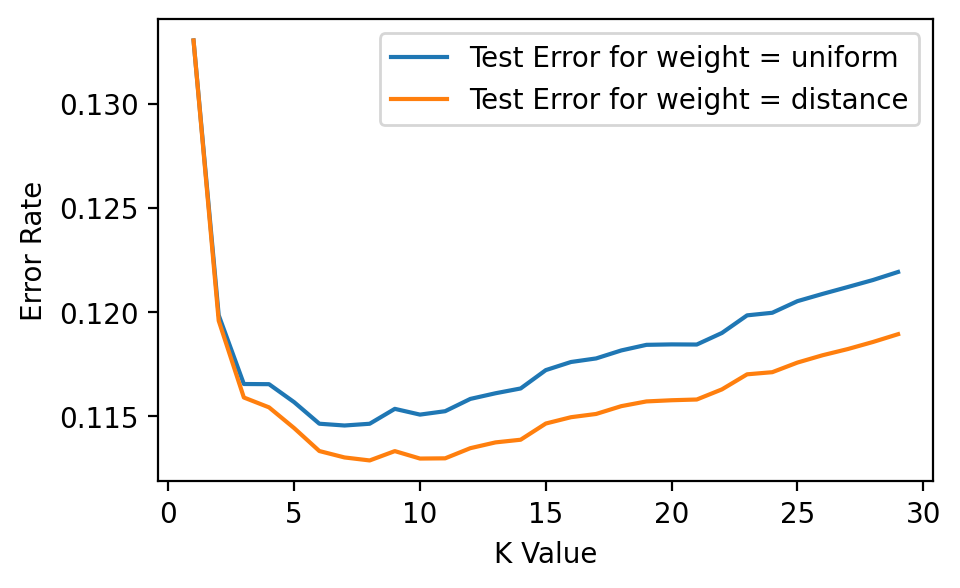

In [ ]:
plt.figure(figsize=(5,3),dpi=200)
plt.plot(range(1,30),test_error_rates_uni,label='Test Error for weight = uniform')

plt.plot(range(1,30),test_error_rates_dist,label='Test Error for weight = distance')

plt.legend()
plt.ylabel('Error Rate')
plt.xlabel("K Value")
plt.show()

In [ ]:
model = KNeighborsRegressor(n_neighbors=10, weights = 'distance')

In [ ]:
model.fit(scaled_topfi_scaletopfi_X_train, y_train)
preds5 = model.predict(scaled_topfi_scaletopfi_X_test)
mape = mean_absolute_percentage_error(y_test, preds5)
rmse = root_mean_squared_error(y_test, preds5)

root mean squared error

In [ ]:
rmse

33835.05460639719

mean absolute percentage error

In [ ]:
mape

0.10179327216221883

### Models 6 : Categorical boosting [mape = 7.51%, rmse = 18110] (our best model)

**Categorical boosting is very useful in that case for two reasons :**

There is no need to do any data preprocessing
- *no need to deal with missing values*
- *no need to do one-hot encoding (witch increases the complexity of our data as we come out with 260 features)*

Cat boost is known to work very well when there are a many features (80 features in our case)

**We still need to do two things before giving the data to our model :**

1) delete the Id features (meaningless feature)

2) Make MSSubClass categorical (The data documentations tell us that it was originally categorical but they converted it to numerical for whatever reason)

In [ ]:
df = pd.read_csv('train.csv')

print(len(df))

df = df.drop(index_outliers)

print(len(df))

df.head()

1460
1458


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
MSSubClass_dict =  {20  :  '1-STORY 1946 & NEWER ALL STYLES',
                    30  :  '1-STORY 1945 & OLDER',
                    40  :  '1-STORY W/FINISHED ATTIC ALL AGES',
                    45  :  '1-1/2 STORY - UNFINISHED ALL AGES',
                    50  :  '1-1/2 STORY FINISHED ALL AGES',
                    60  :  '2-STORY 1946 & NEWER',
                    70  :  '2-STORY 1945 & OLDER',
                    75  :  '2-1/2 STORY ALL AGES',
                    80  :  'SPLIT OR MULTI-LEVEL',
                    85  :  'SPLIT FOYER',
                    90  :  'DUPLEX - ALL STYLES AND AGES',
                    120  :  '1-STORY PUD (Planned Unit Development) - 1946 & NEWER',
                    150  :  '1-1/2 STORY PUD - ALL AGES',
                    160  :  '2-STORY PUD - 1946 & NEWER',
                    180  :  'PUD - MULTILEVEL - INCL SPLIT LEV/FOYER',
                    190  :  '2 FAMILY CONVERSION - ALL STYLES AND AGES'
                    }

df['MSSubClass'] = df['MSSubClass'].apply(lambda n: MSSubClass_dict[n])

In [ ]:
X, y = df.drop(['SalePrice', 'Id'], axis=1), df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

categorical_features = [
    'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
    'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual',
    'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
    'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'
]

# Convert categorical columns to string format (if not already)
X_train[categorical_features] = X_train[categorical_features].astype(str)
X_test[categorical_features] = X_test[categorical_features].astype(str)

# Create a CatBoost Pool (optional but recommended)
train_pool = Pool(X_train, y_train, cat_features = categorical_features)

# Initialize and train the model
catmodel = CatBoostRegressor(verbose=200)

catmodel.fit(train_pool)

Learning rate set to 0.042738
0:	learn: 77675.5395710	total: 90.6ms	remaining: 1m 30s
200:	learn: 17325.6099895	total: 7.06s	remaining: 28.1s
400:	learn: 13753.3751892	total: 15.1s	remaining: 22.5s
600:	learn: 11341.5540257	total: 23s	remaining: 15.3s
800:	learn: 9610.0542701	total: 29.8s	remaining: 7.4s
999:	learn: 8417.1992036	total: 37.9s	remaining: 0us
MAPE :  0.07514709553619917
MAE :  12882.609929205952
RMSE :  18110.232147226423


In [ ]:
catpreds = catmodel.predict(X_test)
print('MAPE : ', mean_absolute_percentage_error(y_test, catpreds))
print('MAE : ', mean_absolute_error(y_test, catpreds))
print('RMSE : ', root_mean_squared_error(y_test, catpreds))

MAPE :  0.07514709553619917
MAE :  12882.609929205952
RMSE :  18110.232147226423


## Expected error visualisation

In [ ]:
comparison = pd.DataFrame(data={'prices' : y_test.values, 'preds': catpreds}).sort_values(by='prices')

In [ ]:
comparison.index = range(len(comparison))

In [ ]:
np.sqrt(((comparison['prices']-comparison['preds'])**2).mean())

np.float64(18110.232147226423)

18100.90255746935

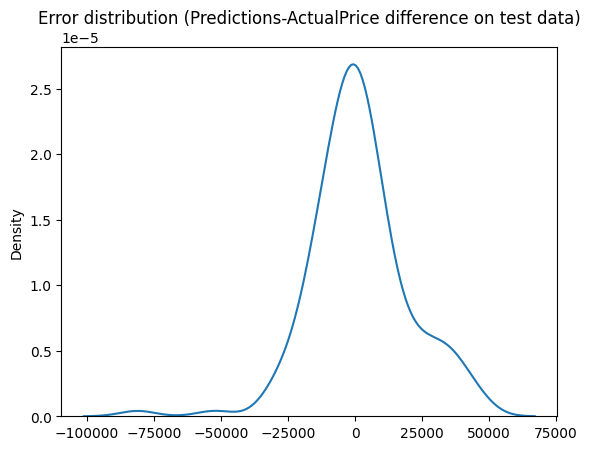

In [ ]:
errors = comparison['preds'] - comparison['prices']
sns.kdeplot(errors)
plt.title('Error distribution (Predictions-ActualPrice difference on test data)')
errors.std()

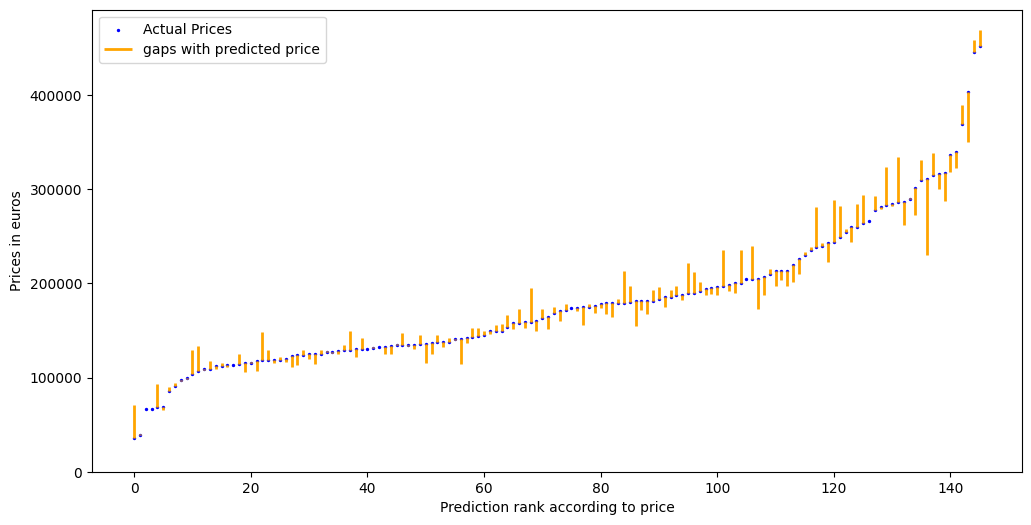

In [ ]:
# plt.figure(figsize=(12, 6))

# plt.plot(comparison.index, comparison['prices'], label="Actual Prices", color='b')
# plt.scatter(comparison.index, comparison['preds'], s=20, color='orange', label="Predictions")

# plt.legend()
# plt.show()

plt.figure(figsize=(12, 6))

# Plot actual prices as a line
plt.scatter(comparison.index, comparison['prices'], label="Actual Prices", color='b', s=2)

# Draw vertical lines showing the difference between actual prices and predictions
plt.vlines(
    x=comparison.index,
    ymin=comparison['preds'],
    ymax=comparison['prices'],
    color='orange',
    linewidth=2
)

# Add a legend
plt.xlabel('Prediction rank according to price')
plt.ylabel('Prices in euros')
plt.ylim(bottom=0)

plt.legend(["Actual Prices", 'gaps with predicted price'])
plt.show()

In [ ]:
comparison.head()

,prices,preds
0,35311,70622.645720
1,39300,39937.356931
2,67000,66615.737967
3,67000,67049.615784
4,68400,92903.417143


In [ ]:
root_mean_squared_error(y_test, catpreds)

18110.232147226423

In [ ]:
mean_absolute_error(y_test, catpreds)

12882.609929205952

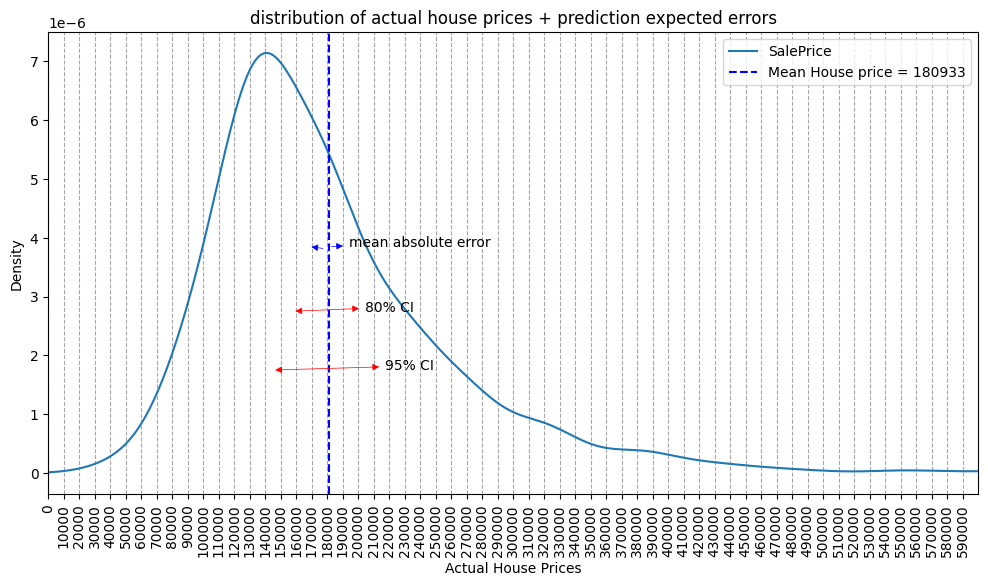

In [ ]:
plt.figure(figsize=(12, 6))

y.plot(kind='kde')

plt.gca().ticklabel_format(style='plain', axis='x')
plt.xticks(np.arange(0, 600000, 10000), rotation=90)
plt.xlim(0, 600000)
plt.grid(axis='x', linestyle='--', color='gray', alpha=0.7)
mean_value = y.mean()
plt.axvline(mean_value, color='blue', linestyle='--', linewidth=1.5, label=f'Mean House price = {mean_value:.0f}')

mae = mean_absolute_error(y_test, catpreds)
confidence_80 = root_mean_squared_error(y_test, catpreds)*1.282
confidence_95 = root_mean_squared_error(y_test, catpreds)*2

y_middle = plt.gca().get_ylim()[1] / 2
y_lower = y_middle - 10**-6
y_lower2 = y_lower - 10**-6

plt.annotate('mean absolute error', xy=(mean_value, y_middle+10**-7),
             xytext=(mean_value + mae, y_middle+10**-7),
             arrowprops=dict(arrowstyle='<|-', color='blue', lw=0.5))

plt.annotate('                   ', xy=(mean_value - mae, y_middle+10**-7),
             xytext=(mean_value, y_middle-10**-7),
             arrowprops=dict(arrowstyle='-|>', color='blue', lw=0.5))

plt.annotate('80% CI',
             xy=(mean_value - confidence_80, y_lower),
             xytext=(mean_value + confidence_80, y_lower),
             arrowprops=dict(arrowstyle='<|-|>', color='red', lw=0.5))

plt.annotate('95% CI',
             xy=(mean_value - confidence_95, y_lower2),
             xytext=(mean_value + confidence_95, y_lower2),
             arrowprops=dict(arrowstyle='<|-|>', color='red', lw=0.5))

plt.xlabel("Actual House Prices")
plt.title("distribution of actual house prices + prediction expected errors")
plt.legend()

plt.show()

## Final Predictions for kaggle

training model on all training data (no portion left for test)

In [ ]:
df = pd.read_csv('train.csv')
df = df.drop(index_outliers)
X, y = df.drop(['SalePrice', 'Id'], axis=1), df['SalePrice']
df.head()

In [ ]:
X_final_test_before_cleaning = pd.read_csv('test.csv')
id_serie = X_final_test_before_cleaning.Id
X_final_test_before_cleaning = X_final_test_before_cleaning.drop('Id', axis=1)

In [ ]:
MSSubClass_dict =  {20  :  '1-STORY 1946 & NEWER ALL STYLES',
                    30  :  '1-STORY 1945 & OLDER',
                    40  :  '1-STORY W/FINISHED ATTIC ALL AGES',
                    45  :  '1-1/2 STORY - UNFINISHED ALL AGES',
                    50  :  '1-1/2 STORY FINISHED ALL AGES',
                    60  :  '2-STORY 1946 & NEWER',
                    70  :  '2-STORY 1945 & OLDER',
                    75  :  '2-1/2 STORY ALL AGES',
                    80  :  'SPLIT OR MULTI-LEVEL',
                    85  :  'SPLIT FOYER',
                    90  :  'DUPLEX - ALL STYLES AND AGES',
                    120  :  '1-STORY PUD (Planned Unit Development) - 1946 & NEWER',
                    150  :  '1-1/2 STORY PUD - ALL AGES',
                    160  :  '2-STORY PUD - 1946 & NEWER',
                    180  :  'PUD - MULTILEVEL - INCL SPLIT LEV/FOYER',
                    190  :  '2 FAMILY CONVERSION - ALL STYLES AND AGES'
                    }

X['MSSubClass'] = X['MSSubClass'].apply(lambda n: MSSubClass_dict[n])
X_final_test_before_cleaning['MSSubClass'] = X_final_test_before_cleaning['MSSubClass'].apply(lambda n: MSSubClass_dict[n])

In [ ]:
X, y = df.drop(['SalePrice', 'Id'], axis=1), df['SalePrice']

categorical_features = [
    'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
    'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual',
    'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
    'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
    'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'
]

# Convert categorical columns to string format (if not already)
X[categorical_features] = X[categorical_features].astype(str)
X_final_test_before_cleaning[categorical_features] = X_final_test_before_cleaning[categorical_features].astype(str)

# Create a CatBoost Pool (optional but recommended)
train_pool = Pool(X, y, cat_features = categorical_features)

# Initialize and train the model
catmodel = CatBoostRegressor(verbose=200)

catmodel.fit(train_pool)

In [ ]:
final_kaggle_preds = catmodel.predict(X_final_test_before_cleaning)

In [ ]:
final_kaggle_preds = pd.DataFrame({'Id' : id_serie, 'SalePrice' : final_kaggle_preds})

In [ ]:
final_kaggle_preds.head()

In [ ]:
final_kaggle_preds.to_csv('final_kaggle_preds.csv', index=False)

**final kaggle score : 0.12330**